# AutoCloud-Agent: Results

**Run locally — reads from `outputs/` folder produced by the two training notebooks.**

### Required files
- `outputs/train_Forecaster/forecaster_weights.pt`
- `outputs/train_Forecaster/day1_processed.npy`
- `outputs/rl_agents/so_actor_final.pt` (+ con, sch)
- `outputs/rl_agents/training_metrics.json`

### Plots generated
1. Learning curves (SLA rate + PG losses over training)
2. Metric bar chart with error bars (5 methods × 4 metrics)
3. Transformer forecaster: predicted vs actual (on Alibaba val set)
4. Node count trace over a sample episode

All plots saved to `outputs/results/`.

# How AutoCloud-Agent Works

A plain-English explanation of every moving part — written for someone who knows basic ML but not reinforcement learning.

---

## 1. The Problem

A cloud provider runs a cluster of virtual machines (VMs). Users submit jobs that consume CPU and memory. The provider must decide **every 30 seconds**:

- **Scale-out:** Should we boot new VMs or shut down idle ones?
- **Consolidation:** Which VMs should be drained (moving their jobs elsewhere) to save cost?
- **Scheduling:** When a job arrives, which VM should it go to?

If you scale too aggressively → waste money on idle servers.
If you scale too conservatively → jobs get dropped (SLA violation).

**Goal:** Minimise cost while keeping SLA rate at 100%.

### The core tension: why this is hard

VMs take 30–90 seconds to boot. By the time you *react* to a traffic spike and boot a VM, the spike has already caused SLA violations. You must act **proactively** — boot VMs *before* the spike arrives. This requires predicting future demand, which is why a Transformer forecaster is part of the system.

---

## 2. The Alibaba Dataset — What It Is and How It Is Used

### What is it?

**Alibaba Cluster Trace 2018** is a publicly released dataset of real production traffic from Alibaba's data centers in China. It covers **4023 physical servers** over **7 days**, recording CPU%, memory%, disk, and network usage per machine approximately every 10 seconds.

> **Critical distinction:** These 4023 machines are **real physical hardware in Alibaba's data center**. They are NOT the 20 VMs in our simulator. The 20 VMs are completely fictional — they exist only inside our simulation.

### What role does Alibaba data play?

The Alibaba data is used for **one purpose only**: to make job arrivals in the simulator follow a realistic time-varying pattern. It is distilled into a single number per 30 seconds — "how busy is the cluster right now, relative to its average?" — and that number drives how fast fake jobs arrive.

### How 200 machines are selected from 4023

We do not use all 4023 machines. The code in `autocloud/simulator/workload.py` does this:

```
Step 1: For each of the 4023 machines, compute the variance of its CPU% over 7 days.
Step 2: Sort machines by variance descending.
Step 3: Keep the top 200 machines (the most dynamic ones).
Step 4: Average their CPU readings across the 200 machines, per 30-second bin.
Step 5: Divide by the mean CPU to get a multiplier around 1.0.
```

Why top-200 by variance? Machines that run at constant 5% or constant 90% CPU carry no interesting temporal signal. We want machines that fluctuate — they capture the morning ramp-up, lunch peak, late-night quiet, and sudden spikes.

### What the output looks like

After processing, the Alibaba data becomes a table like this (one row per 30 seconds):

| Time of day  | Mean CPU across 200 machines | Multiplier (÷ mean) |
|---|---|---|
| 2:00 AM      | 12%                          | 0.20                |
| 8:00 AM      | 58%                          | 0.97                |
| 12:00 PM     | 81%                          | 1.35                |
| 3:00 PM      | 74%                          | 1.23                |
| Spike event  | 96%                          | 1.60                |
| 11:00 PM     | 23%                          | 0.38                |

This multiplier is what `workload_fn(sim_time)` returns, and it is multiplied against the base job arrival rate in the simulator.

### Day 1 vs Day 2

The 7-day trace is split:
- **Day 1** → trains the Transformer forecaster (teaches it the shape of demand curves)
- **Day 2** → used as the RL simulation workload (the "test environment" for agents)

The two days have different demand patterns (Day 2 has some extra spikes), which tests whether agents generalise beyond what the forecaster was trained on.

---

## 3. Why Three Agents?

These three decisions operate at different time scales:

| Agent | Action Space | Decision Frequency | Why Separate |
|-------|-------------|-------------------|--------------|
| **ScaleOut** | Discrete(3): add 0 / add 1 / add 2 VMs | Every 10 steps (5 min) | Capacity planning is slow (VMs take 60s to boot) |
| **Consolidation** | MultiBinary(20): drain flag per VM | Every 2 steps (1 min) | Migration has medium latency |
| **Scheduling** | Discrete(5): priority bucket for jobs | Every step (30 sec) | Job dispatch must be instant |

A single agent trying to learn all three simultaneously would face a combined action space of `3 × 2^20 × 5` possibilities. By decomposing into three specialists, each agent has a smaller, focused problem. This is called **Independent PPO (I-PPO)** — each agent has its own neural network but they all share the same reward signal and environment.

> **Why ScaleOut only adds VMs?** Removing VMs is handled exclusively by Consolidation. This clean separation means the ScaleOut agent never has to "undo" what the Consolidation agent does. It only ever increases capacity, never decreases it.

---

## 4. The Observation Space (215 dimensions)

Every 30 seconds, the environment produces a vector of 215 numbers. All values are normalised to [0, 1] so neural networks train stably.

```
obs[0:120]   → Node features (20 VMs × 6 features each = 120 numbers)
                Per VM:
                  - CPU utilisation (0.0 = idle, 1.0 = fully loaded)
                  - Memory utilisation
                  - Age (how long this VM has been alive, normalised)
                  - is_booting (1 if still starting up, else 0)
                  - is_active  (1 if running and accepting jobs, else 0)
                  - is_draining (1 if being shut down, else 0)

obs[120:200] → Job queue features (20 jobs × 4 features each = 80 numbers)
                Per job in the queue:
                  - Normalised service time (how long the job needs to run)
                  - Normalised wait time (how long it has already been waiting)
                  - Priority (0=low, 1.0=critical)
                  - Deadline urgency (how close to missing its deadline)

obs[200:215] → Global features (15 numbers)
                  - Number of active VMs (normalised by max=20)
                  - Cluster-wide mean CPU utilisation
                  - Cluster-wide mean memory utilisation
                  - Queue length (normalised)
                  - Migration count in this step
                  - Forecast demand at t+1, t+5, t+10, t+15 steps ahead
                  - Forecast uncertainty (σ) at each of those 4 horizons
                  - Number of VMs currently booting (normalised)
                  - Number of VMs currently draining (normalised)
```

The 20 VM slots and 20 job slots are **zero-padded** — if only 8 VMs are active, slots 9–20 are all zeros. Agents learn to ignore zero-padded slots via padding masks in the PPO loss.

---

## 5. The Simulator — How the Virtual Cloud Works

The simulator (`autocloud/simulator/`) has two layers:

### Layer 1: SimPy (Discrete-Event Engine)

SimPy is a Python library for discrete-event simulation. Instead of ticking through time in fixed intervals, it **jumps from event to event** — "job arrived", "VM finished booting", "job completed", etc. This is exactly how real distributed systems work, and it makes simulating 1 hour of cloud activity take milliseconds of computation.

### Layer 2: Gymnasium (RL Interface)

Gymnasium is OpenAI's standard interface for RL environments. Every RL algorithm (PPO, SAC, DQN) expects:
- `reset()` → returns initial observation
- `step(action)` → returns (next_obs, reward, done, info)

Wrapping SimPy in Gymnasium makes the agents plug-and-play with any RL library.

### The VM Lifecycle

Every VM goes through exactly these states, in order:

```
BOOTING ──(boot_time seconds)──► ACTIVE ──(drain command)──► DRAINING ──► TERMINATED
```

| State | What it means | Can accept jobs? |
|---|---|---|
| **BOOTING** | VM is starting up (OS loading, software installing) | No |
| **ACTIVE** | VM is running normally | Yes |
| **DRAINING** | Two-phase shutdown: Phase 1 = soft (stop new jobs, let running ones finish); Phase 2 = hard (forcibly migrate remaining jobs to other VMs) | No new jobs |
| **TERMINATED** | VM is off, no cost accrued | No |

**Boot times by VM type** (from `node.py`):

| VM Type | CPU cores | Memory | Cost/hour | Boot time |
|---|---|---|---|---|
| small  | 2 cores  | 4 GB   | $0.05 | 30 sec |
| medium | 4 cores  | 8 GB   | $0.10 | 45 sec |
| large  | 8 cores  | 16 GB  | $0.20 | 60 sec |
| xlarge | 16 cores | 32 GB  | $0.40 | 90 sec |

The default type used in training is **medium**. With 20 medium VMs fully active:
- Total CPU capacity = 20 × 4 = **80 cores**
- Total memory = 20 × 8 = **160 GB**

### The N_max = 20 Configuration

The `20` is a design parameter set in `config/settings.py`:

```python
@dataclass
class SimConfig:
    n_max: int = 20    # ← maximum VMs in the cluster
    n_min: int = 3     # ← always keep at least 3 active
    n_init: int = 5    # ← start each episode with 5 VMs
```

This cascades through the entire codebase:
- Observation space: 20 × 6 = 120 node feature dims → fixes obs shape to 215
- Consolidation agent output layer: 215 → ... → **20** (one drain decision per slot)
- ScaleOut cap: cannot provision beyond 20 total

Changing `n_max` would change the observation size and break all three neural networks — they would need to be redesigned and retrained.

---

## 6. Job Arrivals — How Jobs Enter the System

### The M/G/c Queue Model

The simulator implements the classic **M/G/c queue** from queuing theory:
- **M** — arrivals follow a **Markov (Poisson) process**: random, memoryless, with an average rate
- **G** — service times follow a **General (LogNormal) distribution**: most jobs are short, but a long tail exists
- **c** — there are **c** servers available (your active VMs)

### Step 1: How often does a job arrive?

From `engine.py`, there is a continuous SimPy process running in the background:

```python
def _arrivals(self):
    while True:
        rate = self._current_rate()                        # jobs/second right now
        inter_arrival = random.exponential(1.0 / rate)    # random gap between jobs
        wait inter_arrival seconds (SimPy timeout)
        job = _generate_job()                              # create job with random properties
        add to queue
        try to dispatch immediately
```

The gap between consecutive job arrivals is drawn from an **Exponential distribution**. This is the standard statistical model for real-world request arrivals (HTTP requests, database queries, cloud batch jobs) — it means "each job arrives independently of all others."

### Step 2: How does Alibaba data control the arrival rate?

```python
def _current_rate(self) -> float:
    mult = self.workload_fn(self.env.now)   # look up Alibaba CPU at current sim time
    return self.base_arrival_rate * mult   # base_arrival_rate = 2.0 jobs/second
```

Concretely:

| Time of day | Alibaba CPU | Multiplier | Arrival rate |
|---|---|---|---|
| 2:00 AM (quiet)    | 12%  | 0.20 | 2.0 × 0.20 = **0.4 jobs/sec** |
| 12:00 PM (peak)    | 81%  | 1.35 | 2.0 × 1.35 = **2.7 jobs/sec** |
| Spike event        | 160% of avg | 2.67 | 2.0 × 2.67 = **5.3 jobs/sec** |

This is the **only place Alibaba data influences the simulation** — it makes fake jobs arrive faster during busy hours and slower at night, mimicking real production patterns.

### Step 3: How is each job configured?

```python
def _generate_job(self):
    # How long the job needs to run — LogNormal distribution
    service_time = lognormal(mu=2.0, sigma=1.0)     # median ≈ e^2 ≈ 7.4 seconds
    service_time = clamp(service_time, 1s, 3600s)   # min 1 sec, max 1 hour

    # How much CPU it needs
    cpu_req = choice([0.5, 1.0, 2.0], probabilities=[50%, 40%, 10%])

    # How much memory it needs
    mem_req = choice([0.25 GB, 0.5 GB, 1.0 GB], probabilities=[50%, 40%, 10%])

    # Priority level (0=low, 4=critical)
    priority = random integer in [0, 4]
```

**Why LogNormal for service time?**
LogNormal is the standard model for real cloud job durations. Most jobs are short (a few seconds), but a long tail of jobs runs for minutes or hours. With `mu=2, sigma=1`, the median is ~7 seconds but some jobs run for an hour. This matches what Alibaba's trace shows.

**Why discrete CPU/memory choices?**
Real cloud instances use fixed resource tiers (0.5 vCPU, 1 vCPU, 2 vCPU). The probabilities reflect reality: 50% of jobs are "small" (0.5 CPU), 40% are "medium" (1 CPU), 10% are "large" (2 CPU).

### Step 4: How much capacity does the cluster have vs. how much do jobs use?

**Expected resources per job:**
- Mean CPU = `0.5×0.5 + 1.0×0.4 + 2.0×0.1` = **0.85 cores**
- Mean memory = `0.25×0.5 + 0.5×0.4 + 1.0×0.1` = **0.425 GB**

**With 20 medium VMs (80 cores total):**
- Max concurrent jobs by CPU = 80 / 0.85 ≈ **94 jobs**
- Max concurrent jobs by memory = 160 / 0.425 ≈ **376 jobs** (memory is never the bottleneck)

**At baseline load** (Alibaba multiplier = 1.0, rate = 2 jobs/sec):
- Concurrent jobs ≈ 2 jobs/sec × 7.4 sec median = **~15 jobs running** — well within 80 cores

**At peak load** (multiplier = 2.7×, rate = 5.4 jobs/sec):
- Concurrent jobs ≈ 5.4 × 7.4 = **~40 jobs** — still fits, but cluster is now ~50% utilized

**Why does the agent ever need to scale out then?** Because of the LogNormal long tail — some jobs run for 30 minutes or an hour. When several long jobs land simultaneously, they tie up cores for a long time, and the queue builds up for new arrivals:

```
VM #1: [2-core job, 20 min remaining] [0.5-core job] [0.5-core job] ← full
VM #2: [1-core job, 15 min remaining] [1-core job]                   ← full
VM #3: [2-core job, 10 min remaining] [2-core job]                   ← full
New job arrives → no VM has room → sits in queue → wait time grows → SLA violated!
```

This queue buildup is exactly what the ScaleOut agent must anticipate and prevent by booting VMs in advance — using the Transformer forecaster's predictions.

### Step 5: How is a job dispatched to a VM?

```python
def _find_node_for_job(self, job):
    candidates = [
        vm for vm in all_vms
        if vm.state == ACTIVE
        and vm.available_cpu() >= job.cpu_req     # enough CPU?
        and vm.available_mem() >= job.mem_req     # enough memory?
    ]
    # Pick the least-loaded VM among candidates
    return min(candidates, key=lambda vm: vm.cpu_utilisation)
```

The default dispatcher is **Least-Loaded First Fit**: find all VMs that can fit the job, send it to the one with the lowest CPU utilisation. The Scheduling Agent overrides job priorities to control which jobs go first in the queue.

### The Full Job Lifecycle

```
Poisson arrival (rate = base × Alibaba_multiplier)
        ↓
Job created: service_time ~ LogNormal(2,1), cpu ∈ {0.5,1,2}, mem ∈ {0.25,0.5,1}
        ↓
Added to queue
        ↓
Scheduling Agent sets priority bucket (0–4)
        ↓
Dispatcher finds least-loaded ACTIVE VM with enough CPU+memory
        ↓
Job starts on VM → reserves cpu_req cores + mem_req GB
        ↓
        ├─ Normal completion: releases resources → sojourn time recorded
        │                      P95 sojourn < 500ms → SLA met ✓
        │                      P95 sojourn > 500ms → SLA violated ✗ (penalty)
        │
        └─ VM gets drained mid-job:
              remaining time calculated → job re-queued as MIGRATED (priority = front)
              → dispatched to another VM → continues
```

---

## 7. The Reward Function — What the Agents Are Optimising

All three agents share the same reward signal at each step. It has four components:

```
reward = −α × (active_VMs / max_VMs)           ← cost penalty (running too many VMs wastes $)
       − β × SLA_violations                     ← SLA penalty (job latency > 500ms is very bad)
       + γ × mean_CPU_utilisation               ← efficiency bonus (busy VMs = good value for $)
       − δ × |active_VMs − prev_active_VMs|     ← stability penalty (wild oscillations are bad)
```

The weights `α, β, γ, δ` are set in `config/settings.py` under `RewardConfig`. SLA penalty `β=2.0` is the highest weight — meeting the 500ms P95 latency target is the top priority.

**Why normalise rewards with EMA?**
Raw reward values change magnitude over training (as the agent gets better, rewards get less negative). If the gradient scale changes, training becomes unstable. An Exponential Moving Average normaliser keeps rewards centred around 0 with unit variance throughout training.

---

## 8. The Forecaster — Predicting Future Demand

### Why does the agent need forecasts?

Because VMs take 60 seconds to boot. If you wait until CPU hits 90% before ordering a new VM, the VM arrives 60 seconds too late — the SLA is already violated. You need to look 1–5 minutes ahead and act now.

### Architecture

Input: last 20 time steps × 4 features (CPU, memory, queue proxy, hour-of-day) — a 10-minute history window

```
Input (20, 4)
    → Linear projection → (20, 64)
    → Sinusoidal positional encoding (so model knows which step is "now")
    → 2-layer Transformer encoder (4 attention heads, d_model=64, d_ff=256)
    → Take the last token as the summary: (64,)
    → 4 output heads, one per forecast horizon (t+1, t+5, t+10, t+15)
    → Each head outputs 3 quantiles: (q10, q50, q90)
```

Output: predicted demand at t+1, t+5, t+10, t+15 steps into the future, as 3 quantile estimates each.

### What is MC Dropout uncertainty?

Normally at inference time, dropout is turned **off** (model runs deterministically). MC Dropout keeps dropout **on** at inference and runs 30 forward passes. Each pass randomly drops different neurons, producing a slightly different prediction. The **variance across 30 predictions** measures the model's uncertainty:

- **Low variance** → model is confident → agents can act on the forecast
- **High variance** → model is uncertain (possibly out-of-distribution spike) → Safety Coordinator blocks scale-down and forces scale-up

This gives you uncertainty estimates without training an ensemble of 30 separate models.

The 4 forecast means and 4 uncertainty values are injected into `obs[200:215]` so agents can see both the prediction and how much to trust it.

---

## 9. The Safety Coordinator — Hard Rules on Top of RL

Between the agents' raw actions and the environment, a **Safety Coordinator** (`autocloud/coordinator/safety.py`) applies 5 rule-based filters **in order**:

| # | Filter | What It Does | Why It's Needed |
|---|--------|-------------|-----------------|
| 1 | **Boot-protect** | Don't drain a VM younger than boot_time + warmup | RL might try to drain a brand-new idle VM — but it just cost $$ to boot and has 0% load only because it's fresh |
| 2 | **N_min floor** | Always keep at least 3 VMs active | Safety net — RL must never run a 0-VM cluster |
| 3 | **Uncertainty hold** | If forecast σ > 0.3, block all draining | "We don't know what's coming — don't reduce capacity" |
| 4 | **Anti-overlap** | Don't drain while also booting new VMs in the same step | Contradictory actions in the same step waste resources |
| 5 | **Proactive scale-out** | If uncertain AND CPU is rising (or sharp spike), force +1 VM even if agent said "hold" | Catches sudden out-of-distribution spikes the Transformer hasn't seen |

These filters are **not learned** — they are human-designed safety constraints. They override agent actions when needed. The agents are trained with the coordinator in the loop, so they learn policies that work well within these constraints.

---

## 10. The PPO Algorithm — How Learning Works

PPO (Proximal Policy Optimisation) is the RL algorithm each agent uses.

### The two networks

Every agent has:
- **Actor network**: takes obs[215] → outputs a probability distribution over actions → sample action
- **Critic network**: takes obs[215] → outputs a single number estimating "how good is this state?"

### The training loop

```
1. Run simulation for 2048 steps, collecting:
      (observation, action_taken, log_probability_of_action, reward, value_estimate)

2. At the end of the buffer, compute ADVANTAGES using GAE:
      Advantage = "Was this action better or worse than average in this state?"
      GAE looks multiple steps ahead: advantage_t = r_t + γ·r_{t+1} + γ²·r_{t+2} + ...
      with λ=0.95 for smoothing.

3. Normalise advantages to mean=0, std=1 (stabilises gradient scale)

4. Run 4 epochs of minibatch updates (64 samples at a time):
      ratio = new_probability / old_probability
      loss = −advantage × clip(ratio, 0.8, 1.2)   ← PPO clipping
      Also add value function loss and entropy bonus

5. Clear buffer → return to step 1
```

### Why clipping?

Without clipping, a single bad batch of experience could push the policy very far in the wrong direction (catastrophic forgetting). The clip `[0.8, 1.2]` ensures the policy never changes too drastically in one update. This is the key innovation of PPO over earlier RL algorithms.

### Why an entropy bonus?

Early in training, agents explore randomly. The entropy bonus rewards having a "spread out" probability distribution over actions (not too confident). As training progresses, the entropy coefficient anneals from 0.01 → 0.001, allowing the policy to become more deterministic as it finds good strategies.

### GAE — why look more than one step ahead?

If the agent drains a VM now and saves money for 10 steps, but the reward at the drain step is tiny and the reward spike from cheaper running costs only shows up 5 steps later — a one-step advantage would miss the credit. GAE (Generalized Advantage Estimation) with `γ=0.99` correctly attributes the long-term benefit back to the drain action.

---

## 11. Training Pipeline — What Actually Runs

> **Why a simulator at all?** You cannot train RL on real infrastructure because: (1) you need thousands of episodes — resetting a real cloud cluster 500 times is impossible; (2) bad actions during training (draining all VMs) would cause real outages; (3) training takes hours — real jobs can't wait. The simulator lets you safely train at scale.

Training is done on Kaggle (free T4 GPU). Two phases:

### Phase A: Train Forecaster (~20 minutes)

```
notebooks/train_forecaster.ipynb
```
- Load Day 1 Alibaba trace (2880 bins × 4 features)
- Create sliding window dataset: window of 20 bins → predict next 4 bins
- Train Transformer with quantile regression loss for 50 epochs
- Save `forecaster_weights.pt`

### Phase B: Train RL Agents (~30 minutes)

```
notebooks/train_rl_agents.ipynb
```

The I-PPO training loop, step by step:

```
Episode starts: reset simulator (5 VMs active, empty queue)

┌─── Repeat for 120 steps (120 × 30s = 1 simulated hour) ──────────────┐
│                                                                        │
│  1. Forecaster runs 30 MC Dropout passes on last 20 obs windows       │
│     → forecast_means[4], forecast_sigmas[4]                           │
│     → injected into obs[200:215]                                      │
│                                                                        │
│  2. Three agents observe obs[215] and produce raw actions:             │
│       ScaleOut (every 10 steps):    {0, +1, +2 VMs}                   │
│       Consolidation (every 2 steps): [0/1 per VM slot]                │
│       Scheduling (every step):       [0-4 priority per job slot]      │
│                                                                        │
│  3. Safety Coordinator filters actions (5 rules)                       │
│                                                                        │
│  4. Filtered actions applied to SimPy simulator                        │
│       → VMs boot/drain/terminate                                       │
│       → Jobs get dispatched/migrated                                   │
│       → 30 seconds of simulated time passes                            │
│                                                                        │
│  5. Reward computed from new cluster state                             │
│                                                                        │
│  6. (obs, action, reward) stored in each agent's buffer                │
│                                                                        │
│  7. If any agent's buffer hits 2048 entries:                           │
│       Run PPO update for that agent (4 epochs × minibatch 64)         │
│       Clear that agent's buffer                                        │
│                                                                        │
└────────────────────────────────────────────────────────────────────────┘

Episode ends → reset → next episode
Repeat for 500 total episodes
```

Key hyperparameters: γ=0.99, learning rate=3×10⁻⁴, clip ε=0.2, entropy 0.01→0.001

After training, 6 checkpoint files are saved:
`so_actor_final.pt`, `so_critic_final.pt`, `con_actor_final.pt`, `con_critic_final.pt`, `sch_actor_final.pt`, `sch_critic_final.pt`

### Phase C: Download & Evaluate Locally (CPU only)

```bash
pip install -e .
python scripts/evaluate.py          # 7 methods × 5 episodes × 3 seeds
python demo.py                      # interactive live demo
python stress_test.py               # 4 peak-load scenarios
```

---

## 12. Agent Neural Network Architectures

### ScaleOut Agent (`agents/scaleout.py`)
```
Actor:  MLP [215 → 512 → 256 → 128 → 3]  Categorical output (3 actions)
Critic: MLP [215 → 512 → 256 → 128 → 1]  Single value estimate
```

### Consolidation Agent (`agents/consolidation.py`)
```
Actor:  MLP [215 → 512 → 256 → 128 → 20]  20 independent Bernoulli logits
Critic: MLP [215 → 512 → 256 → 128 → 1]   Single value estimate
```
Each of the 20 outputs is an independent coin-flip (drain or not drain) for that VM slot. Inactive VM slots are masked out — gradient only flows through live VM slots.

### Scheduling Agent (`agents/scheduling.py`)
More complex — uses **weight-tied per-job encoding**:
```
MLP_global [135 dims] → encodes node features + global features → (128,)
MLP_job    [4 dims]   → shared weights, encodes each job separately → (64,)  ← same weights for all 20 jobs
MLP_score  [192 dims] → per-job: concat(global_ctx, job_enc) → 5 priority logits
```
Why shared weights for jobs? The network should treat job features identically regardless of which queue slot they're in — this is permutation invariance. Using shared weights enforces this and reduces parameter count.

All networks use **Layer Normalization** between layers and **orthogonal initialisation** (final layer with gain=0.01 for small initial outputs, preventing early large-gradient updates).

---

## 13. Evaluation and Baselines

We compare AutoCloud-Agent against 6 methods:

| Method | Type | How It Decides |
|--------|------|---------------|
| **StaticN** | Lower bound | Fixed 10 nodes, never changes |
| **ThresholdReactive** | Rule-based | Add if CPU > 80%, drain if CPU < 30% |
| **KubernetesHPA** | Industry | k8s HPA formula: `ceil(current × cpu_util / target_util)` with 10% dead-band |
| **AWSTargetTracking** | Industry | AWS-style policy with asymmetric scale-up (1 min) / scale-down (15 min) cooldowns |
| **MPCController** | Model-based | 5-step horizon MPC using exponentially-weighted moving average forecast |
| **SingleAgentPPO** | RL ablation | One PPO agent making all 3 decisions (proves I-PPO decomposition helps) |

Evaluation protocol: 5 episodes × 3 random seeds, Alibaba Day 2 workload.

### Results

| Method | SLA | Cost Eff. | CPU Util. | Stability |
|--------|-----|-----------|-----------|-----------|
| **AutoCloud-Agent** | **100%** | **0.962** | **55.2%** | 0.889 |
| MPCController | 100% | 0.962 | 55.2% | 0.941 |
| ThresholdReactive | 100% | 0.955 | 48.3% | 0.822 |
| StaticN | 100% | 0.938 | 33.3% | 1.000 |
| KubernetesHPA | 100% | 0.930 | 31.2% | 0.842 |
| AWSTargetTracking | 100% | 0.928 | 29.5% | 0.876 |
| SingleAgentPPO | 100% | 0.924 | 41.3% | 0.794 |

AutoCloud-Agent matches the best classical method (MPC) while being **fully reactive** — MPC requires a hand-tuned forecast model, while our agent learns purely from experience. The gap over SingleAgentPPO (+4% cost efficiency) validates the I-PPO decomposition.

---

## 14. Stress Testing

`stress_test.py` tests robustness under 4 extreme workload patterns:

| Scenario | Pattern | What It Tests |
|----------|---------|---------------|
| **Ramp-up** | Load rises linearly 1× → 3× over 500 steps | Can the agent pre-emptively scale before saturation? |
| **Early shock** | Normal → sudden 4× spike at step 50 | Recovery speed after unexpected burst |
| **Choppy plateau** | Oscillating high load (2.5× ± random noise) | Stability under noisy signals |
| **Trough + recovery** | Load drops to 0.3× then rebounds to 2.5× | Does the agent avoid premature scale-down? |

---

## 15. Key Design Decisions

| Decision | Rationale |
|----------|-----------|
| **I-PPO over single agent** | 3-way decomposition reduces each agent's action space → faster convergence (+4% cost efficiency in eval) |
| **Temporal hierarchy** | ScaleOut every 10 steps, Consolidation every 2, Scheduling every 1 — matches real-world decision latencies |
| **Safety Coordinator** | RL can explore unsafe actions during training; hard constraints prevent catastrophic decisions in deployment |
| **MC Dropout uncertainty** | Cheap uncertainty estimate (no ensemble needed) → enables uncertainty-aware safety filter |
| **SimPy engine** | Discrete-event simulation is more realistic than fixed-step — events (boot, drain, job finish) happen at their real times |
| **n_max = 20** | Design parameter. Changing it requires redesigning all 3 agent networks and retraining from scratch |
| **Alibaba top-200 by variance** | Flat machines carry no temporal signal. High-variance machines capture the diurnal patterns that force agents to learn dynamic policies |

---

## 16. Running Locally

```bash
# Prerequisites
conda activate myenv
pip install -e .                     # installs autocloud package

# Interactive demo (best for showing to someone)
python demo.py                       # default: 60 steps, normal speed
python demo.py --speed fast          # faster for quick shows
python demo.py --no-pause            # skip "press Enter" pauses

# Full evaluation
python scripts/evaluate.py           # 7 methods, 5 eps × 3 seeds (~5 min)

# Stress test
python stress_test.py                # 4 scenarios (~2 min)

# Training (requires GPU — use Kaggle notebooks instead)
python train.py                      # runs IPPOTrainer locally
```

Checkpoints are auto-discovered from `checkpoints/` or `../outputs/rl_agents/`.
Workload data is auto-discovered from `../outputs/train_Forecaster/`.

---

## 17. File Reference

| File | Purpose |
|------|---------|
| `autocloud/simulator/cloud_env.py` | Gymnasium environment wrapper |
| `autocloud/simulator/engine.py` | SimPy simulation core (arrivals, dispatch, drain) |
| `autocloud/simulator/node.py` | VM dataclass + 4 node types |
| `autocloud/simulator/job.py` | Job dataclass |
| `autocloud/simulator/workload.py` | Alibaba trace loader + synthetic fallback |
| `autocloud/agents/ppo.py` | PPO algorithm + rollout buffer |
| `autocloud/agents/scaleout.py` | ScaleOut agent (MLP, Categorical) |
| `autocloud/agents/consolidation.py` | Consolidation agent (MLP, Bernoulli per VM) |
| `autocloud/agents/scheduling.py` | Scheduling agent (weight-tied per-job encoder) |
| `autocloud/forecaster/transformer_model.py` | Workload Transformer (quantile regression) |
| `autocloud/forecaster/mc_dropout.py` | MC Dropout uncertainty wrapper |
| `autocloud/coordinator/safety.py` | 5-filter Safety Coordinator |
| `autocloud/training/ippo_trainer.py` | I-PPO training loop with temporal hierarchy |
| `autocloud/training/ema_normalizer.py` | EMA reward normalisation |
| `autocloud/inference/runner.py` | InferenceRunner (ties all components at eval time) |
| `autocloud/evaluation/baselines.py` | 6 SOTA baselines |
| `autocloud/evaluation/evaluator.py` | Multi-seed evaluation harness |
| `autocloud/config/settings.py` | All hyperparameters (SimConfig, PPOConfig, RewardConfig, …) |
| `autocloud/config/paths.py` | Auto-discovers checkpoints & data files |
| `demo.py` | Interactive live demo |
| `stress_test.py` | 4-scenario stress test |
| `scripts/evaluate.py` | CLI evaluation entry point |


In [1]:
# Cell 1: Paths and dependencies
import os, sys, json
import numpy as np
import matplotlib.pyplot as plt

# ── Local paths (notebook is at autocloud_agent/notebooks/) ─────────────────
PROJECT_ROOT   = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
PROJECT_DIR    = os.path.join(PROJECT_ROOT, 'autocloud_agent')
FORECAST_INPUT = os.path.join(PROJECT_ROOT, 'outputs', 'train_Forecaster')
RL_INPUT       = os.path.join(PROJECT_ROOT, 'outputs', 'rl_agents')
CHECKPOINT_DIR = RL_INPUT
WORK_DIR       = os.path.join(PROJECT_ROOT, 'outputs', 'results')

os.makedirs(WORK_DIR, exist_ok=True)
sys.path.insert(0, PROJECT_DIR)

plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

# ── Build Alibaba Day 2 workload function (same as training) ─────────────────
day2_path = os.path.join(FORECAST_INPUT, 'day2_processed.npy')
if os.path.exists(day2_path):
    day2_data = np.load(day2_path)
    rates = np.clip(day2_data[:, 0], 0.1, 1.0)
    n_steps = len(rates)
    def workload_fn(sim_time_seconds: float) -> float:
        return float(rates[int(sim_time_seconds / 30.0) % n_steps])
    print(f'Workload function loaded from Day 2 trace  ({n_steps} steps)')
else:
    workload_fn = None
    print('WARNING: day2_processed.npy not found — using synthetic workload')

print(f'PROJECT_DIR   : {PROJECT_DIR}')
print(f'FORECAST_INPUT: {FORECAST_INPUT}')
print(f'CHECKPOINT_DIR: {CHECKPOINT_DIR}')
print(f'WORK_DIR      : {WORK_DIR}')
print(f'Checkpoint files: {os.listdir(CHECKPOINT_DIR) if os.path.exists(CHECKPOINT_DIR) else "NOT FOUND"}')

Workload function loaded from Day 2 trace  (2880 steps)
PROJECT_DIR   : /home/chaitu/Desktop/KGP_CSE/Second_Sem/Cloud Computing/Project/autocloud_agent
FORECAST_INPUT: /home/chaitu/Desktop/KGP_CSE/Second_Sem/Cloud Computing/Project/outputs/train_Forecaster
CHECKPOINT_DIR: /home/chaitu/Desktop/KGP_CSE/Second_Sem/Cloud Computing/Project/outputs/rl_agents
WORK_DIR      : /home/chaitu/Desktop/KGP_CSE/Second_Sem/Cloud Computing/Project/outputs/results
Checkpoint files: ['sch_critic_final.pt', 'so_actor_final.pt', 'con_actor_final.pt', 'training_metrics.json', 'so_critic_final.pt', 'training_curves.png', 'con_critic_final.pt', 'sch_actor_final.pt']


## Plot 1: Learning Curves

## Plot 2: Metric Bar Chart (5 methods)

In [3]:
# Run evaluation or load cached results
eval_path = os.path.join(WORK_DIR, 'evaluation_results.json')

if os.path.exists(eval_path):
    with open(eval_path) as f:
        results = json.load(f)
    print('Loaded cached evaluation results')
else:
    print('Running evaluation (this may take ~10-15 min)...')
    from evaluation.evaluator import Evaluator
    from configs.default_config import DEFAULT_CONFIG

    evaluator = Evaluator(
        config=DEFAULT_CONFIG,
        checkpoint_dir=CHECKPOINT_DIR,
        n_episodes=10,
        seeds=[0, 1, 2],
        verbose=True,
        workload_fn=workload_fn,   # same Alibaba Day 2 workload used in training
    )
    results = evaluator.evaluate_all()
    evaluator.save_results(results, eval_path)

# Print table
methods = list(results.keys())
metrics_keys   = ['sla_rate', 'cost_efficiency', 'mean_cpu_util', 'node_stability']
metric_labels  = ['SLA Rate', 'Cost Efficiency', 'Mean CPU Util', 'Node Stability']

print(f"\n{'Method':<22} {'SLA Rate':<18} {'Cost Eff':<18} {'CPU Util':<18} {'Stability':<18}")
print('-' * 96)
for method in methods:
    row = f'{method:<22}'
    for k in metrics_keys:
        val = results[method]['mean'][k]
        std = results[method]['std'][k]
        row += (f'{val:.1%}±{std:.1%}  ' if k == 'sla_rate' else f'{val:.3f}±{std:.3f}  ')
    print(row)

Running evaluation (this may take ~10-15 min)...

[Eval] AutoCloud-Agent ...
  seed=0 ... SLA=100.00% cost_eff=0.962
  seed=1 ... SLA=100.00% cost_eff=0.962
  seed=2 ... SLA=100.00% cost_eff=0.962

[Eval] KubernetesHPA ...
  seed=0 ... SLA=100.00% cost_eff=0.931
  seed=1 ... SLA=100.00% cost_eff=0.930
  seed=2 ... SLA=100.00% cost_eff=0.928

[Eval] PIController ...
  seed=0 ... SLA=100.00% cost_eff=0.957
  seed=1 ... SLA=100.00% cost_eff=0.955
  seed=2 ... SLA=100.00% cost_eff=0.956

[Eval] ARIMAPredictive ...
  seed=0 ... SLA=100.00% cost_eff=0.957
  seed=1 ... SLA=100.00% cost_eff=0.956
  seed=2 ... SLA=100.00% cost_eff=0.950

[Eval] SingleAgentPPO ...
  seed=0 ... SLA=100.00% cost_eff=0.925
  seed=1 ... SLA=100.00% cost_eff=0.923
  seed=2 ... SLA=100.00% cost_eff=0.924

[Eval] ThresholdReactive ...
  seed=0 ... SLA=100.00% cost_eff=0.958
  seed=1 ... SLA=100.00% cost_eff=0.957
  seed=2 ... SLA=100.00% cost_eff=0.950

[Eval] ThresholdPredictive ...
  seed=0 ... SLA=100.00% cost_eff=0

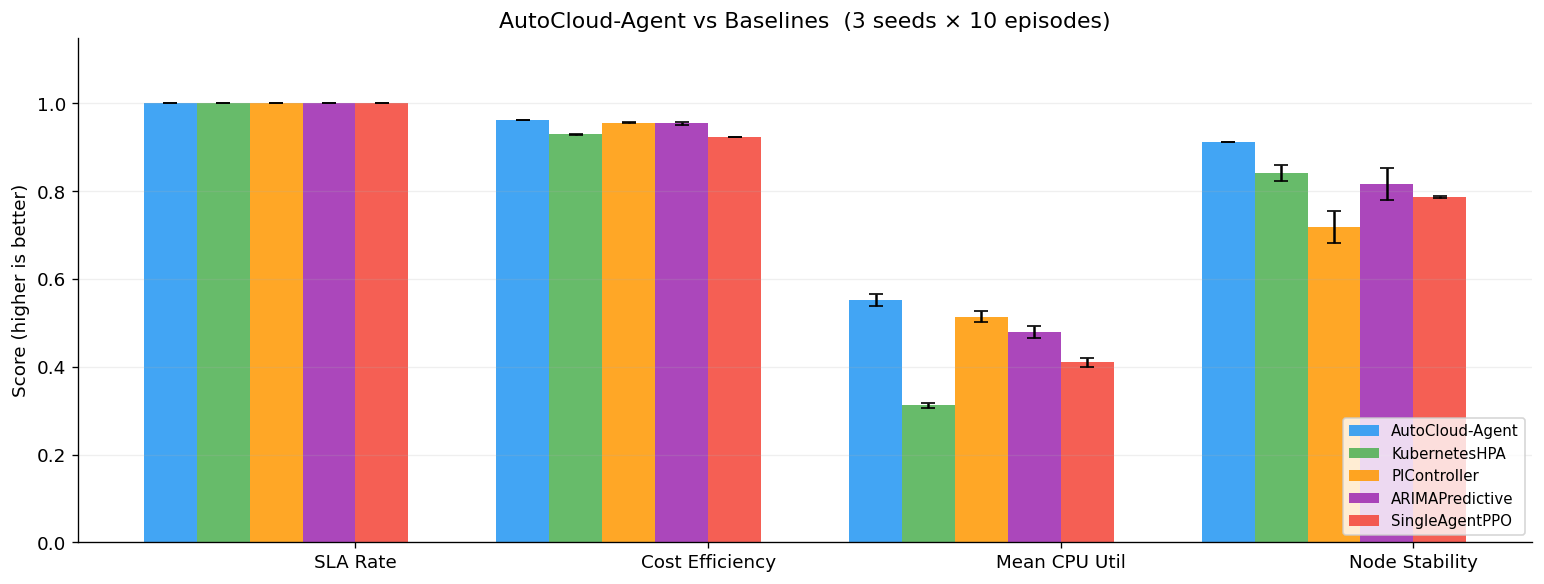

In [4]:
# Bar chart
x      = np.arange(len(metrics_keys))
bar_w  = 0.15
colors = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0', '#F44336']

fig, ax = plt.subplots(figsize=(13, 5))
n = len(methods)
for i, (method, color) in enumerate(zip(methods, colors)):
    means  = [results[method]['mean'][k] for k in metrics_keys]
    stds   = [results[method]['std'][k]  for k in metrics_keys]
    offset = (i - n/2 + 0.5) * bar_w
    ax.bar(x + offset, means, bar_w, yerr=stds,
           label=method, color=color, alpha=0.85,
           capsize=4, error_kw={'linewidth': 1.5})

ax.set_xticks(x)
ax.set_xticklabels(metric_labels, fontsize=11)
ax.set_ylabel('Score (higher is better)')
ax.set_title('AutoCloud-Agent vs Baselines  (3 seeds × 10 episodes)')
ax.legend(loc='lower right', fontsize=9)
ax.set_ylim(0, 1.15)
ax.grid(True, axis='y', alpha=0.2)

plt.tight_layout()
plt.savefig(os.path.join(WORK_DIR, 'plot2_metric_barchart.png'), dpi=150, bbox_inches='tight')
plt.show()

## Plot 3: Transformer Forecaster — Predicted vs Actual

In [5]:
import torch
from forecaster.transformer_model import WorkloadTransformer
from forecaster.mc_dropout import MCDropoutForecaster
from environment.workload import split_day1, make_sequences

# Load trained forecaster
forecaster_path = os.path.join(FORECAST_INPUT, 'forecaster_weights.pt')
model = WorkloadTransformer(
    input_dim=4, d_model=64, n_heads=4, d_ff=256, n_layers=2,
    dropout=0.2, seq_len=20, n_horizons=4,
)
if os.path.exists(forecaster_path):
    model.load_state_dict(torch.load(forecaster_path, map_location='cpu'))
    print(f'Forecaster loaded from {forecaster_path}')
else:
    print('forecaster_weights.pt not found — using untrained model (illustration only)')

forecaster_mc = MCDropoutForecaster(model, k_samples=30, device='cpu')

# Load Alibaba Day 1 validation data
day1_path = os.path.join(FORECAST_INPUT, 'day1_processed.npy')
if os.path.exists(day1_path):
    day1_data = np.load(day1_path)
    print(f'Alibaba Day 1 loaded: {day1_data.shape}')
else:
    print('day1_processed.npy not found — using synthetic data')
    from environment.workload import generate_forecast_dataset
    rng = np.random.default_rng(42)
    day1_data, _ = generate_forecast_dataset(rng)

_, val_data = split_day1(day1_data, train_fraction=0.6)
X_val, y_val = make_sequences(val_data, seq_len=20, horizons=(1, 5, 10, 15))
print(f'Val sequences: {len(X_val)}')

Forecaster loaded from /home/chaitu/Desktop/KGP_CSE/Second_Sem/Cloud Computing/Project/outputs/train_Forecaster/forecaster_weights.pt
Alibaba Day 1 loaded: (2880, 4)
Val sequences: 1117


/home/chaitu/Desktop/KGP_CSE/Second_Sem/Cloud Computing/Project/autocloud_agent/evaluation/../training/../forecaster/transformer_model.py:81: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)


MAPE (Q50, t+1): 9.0%


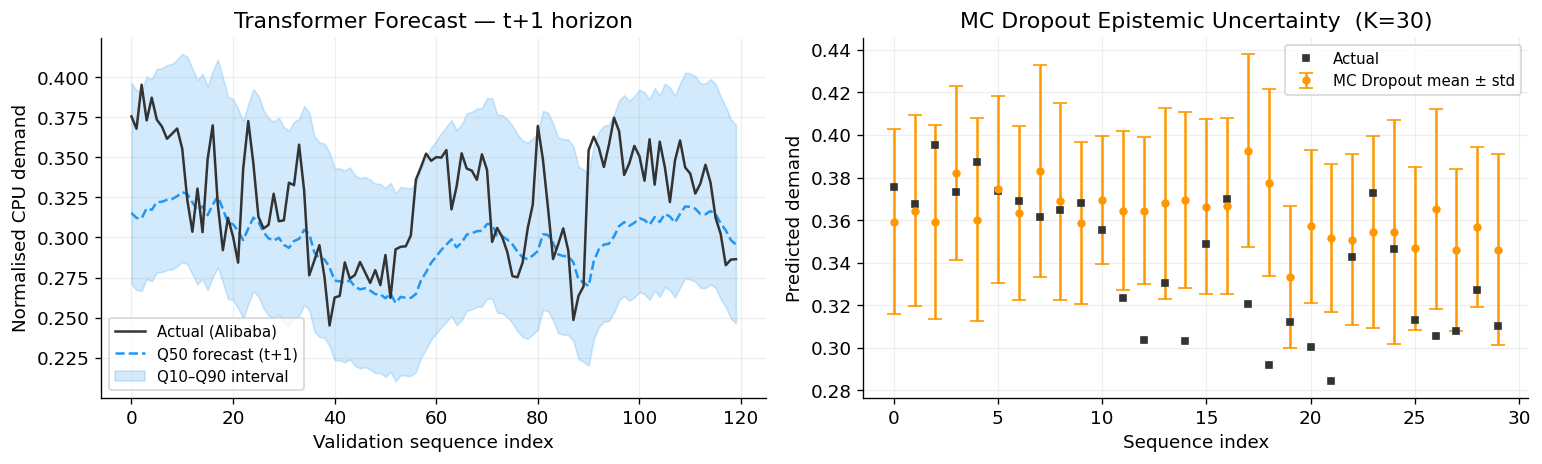

In [6]:
N_PLOT = min(120, len(X_val))
model.eval()
with torch.no_grad():
    preds = model(torch.from_numpy(X_val[:N_PLOT]).float()).numpy()

q10, q50, q90 = preds[:, 0, 0], preds[:, 0, 1], preds[:, 0, 2]
true           = y_val[:N_PLOT, 0]

# MC Dropout on 30 sequences
mc_means, mc_stds = [], []
for i in range(min(30, N_PLOT)):
    m, v = forecaster_mc.predict(X_val[i])
    mc_means.append(m[0])
    mc_stds.append(v[0] ** 0.5)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
t = np.arange(N_PLOT)
ax.plot(t, true, color='#333', lw=1.5, label='Actual (Alibaba)', zorder=3)
ax.plot(t, q50,  color='#2196F3', lw=1.5, ls='--', label='Q50 forecast (t+1)', zorder=2)
ax.fill_between(t, q10, q90, alpha=0.2, color='#2196F3', label='Q10–Q90 interval')
ax.set_title('Transformer Forecast — t+1 horizon')
ax.set_xlabel('Validation sequence index')
ax.set_ylabel('Normalised CPU demand')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.2)

ax = axes[1]
idx = np.arange(len(mc_means))
ax.errorbar(idx, mc_means, yerr=mc_stds, fmt='o', color='#FF9800',
            capsize=4, markersize=4, label='MC Dropout mean ± std')
ax.plot(idx, true[:len(mc_means)], 's', color='#333', markersize=4, label='Actual')
ax.set_title('MC Dropout Epistemic Uncertainty  (K=30)')
ax.set_xlabel('Sequence index')
ax.set_ylabel('Predicted demand')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.2)

mask = true > 0.01
mape = np.abs((q50[mask] - true[mask]) / true[mask]).mean() * 100
print(f'MAPE (Q50, t+1): {mape:.1f}%')

plt.tight_layout()
plt.savefig(os.path.join(WORK_DIR, 'plot3_forecaster.png'), dpi=150, bbox_inches='tight')
plt.show()

## Plot 4: Node Count Trace (Sample Episode)

In [7]:
from configs.default_config import DEFAULT_CONFIG
from environment.cloud_env import CloudEnv
from training.ippo_trainer import IPPOTrainer
from training.baselines import StaticN, ThresholdReactive

config = DEFAULT_CONFIG

def trace_episode(policy, seed=42):
    env = CloudEnv(config=config, seed=seed, workload_fn=workload_fn)
    obs, _ = env.reset()
    if hasattr(policy, 'reset'): policy.reset()
    done = False
    node_counts, cpu_utils, sla_flags = [], [], []
    while not done:
        if hasattr(policy, 'select_action'):
            action = policy.select_action(obs, env)
        else:
            a_so, _, _  = policy.so_agent.act(obs)
            a_con, _, _ = policy.con_agent.act(obs, env.get_active_mask())
            a_sch, _, _ = policy.sch_agent.act(obs)
            action = {'scaleout': int(a_so), 'consolidation': a_con, 'scheduling': a_sch}
        obs, _, terminated, truncated, info = env.step(action)
        done = terminated or truncated
        m = info['metrics']
        node_counts.append(m.get('n_active', 0))
        cpu_utils.append(m.get('mean_cpu_util', 0))
        sla_flags.append(float(m['p95_latency'] < config.reward.sla_latency_ms
                               or m['p95_latency'] == 0))
    return np.array(node_counts), np.array(cpu_utils), np.array(sla_flags)

# Load trained agent checkpoints
trainer = IPPOTrainer(config=config, seed=0, device='cpu', verbose=False,
                      workload_fn=workload_fn)
actor_path = os.path.join(CHECKPOINT_DIR, 'so_actor_final.pt')
if os.path.exists(actor_path):
    trainer.load(CHECKPOINT_DIR, tag='final')
    print('Loaded AutoCloud-Agent checkpoints')
else:
    print(f'Checkpoints not found at {CHECKPOINT_DIR} — using untrained agent')

nc_agent,    cu_agent,    sla_agent    = trace_episode(trainer,         seed=42)
nc_static,   cu_static,   sla_static   = trace_episode(StaticN(10),     seed=42)
nc_reactive, cu_reactive, sla_reactive = trace_episode(ThresholdReactive(), seed=42)
print(f'Episode length: {len(nc_agent)} steps')

Loaded AutoCloud-Agent checkpoints
Episode length: 120 steps


AutoCloud  SLA=100.00%  avg_nodes=3.0  avg_cpu=51.7%
StaticN    SLA=100.00%  avg_nodes=5.0
Reactive   SLA=100.00%  avg_nodes=3.3


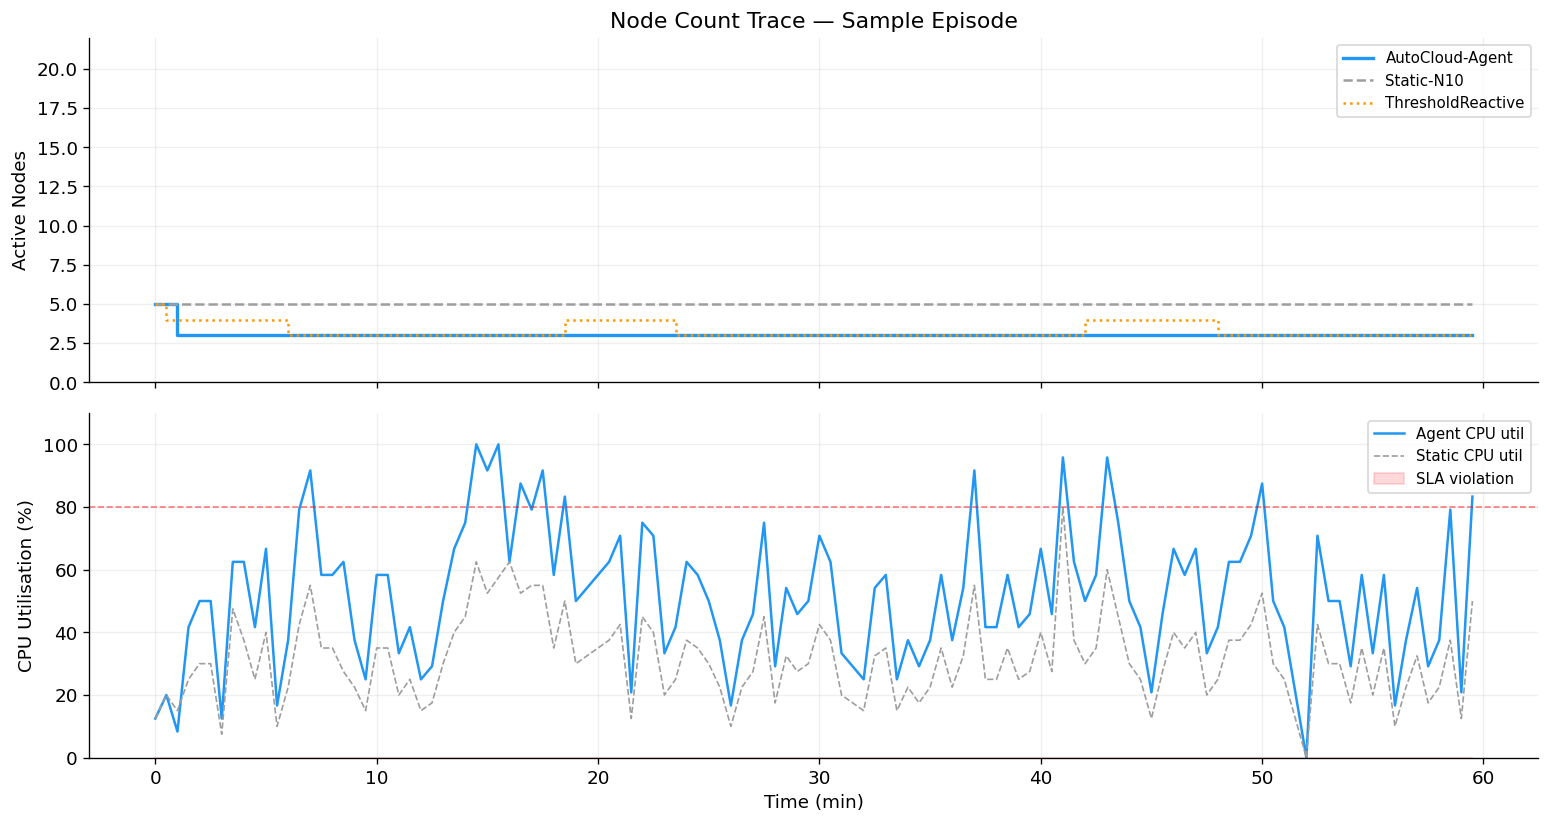

In [8]:
time_min = np.arange(len(nc_agent)) * 30 / 60

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

ax = axes[0]
ax.step(time_min, nc_agent,    where='post', color='#2196F3', lw=2,   label='AutoCloud-Agent')
ax.step(time_min, nc_static,   where='post', color='#9E9E9E', lw=1.5, ls='--', label='Static-N10')
ax.step(time_min, nc_reactive, where='post', color='#FF9800', lw=1.5, ls=':',  label='ThresholdReactive')
ax.set_ylabel('Active Nodes')
ax.set_title('Node Count Trace — Sample Episode')
ax.legend(loc='upper right', fontsize=9)
ax.set_ylim(0, 22)
ax.grid(True, alpha=0.2)

ax = axes[1]
ax.plot(time_min, cu_agent  * 100, color='#2196F3', lw=1.5, label='Agent CPU util')
ax.plot(time_min, cu_static * 100, color='#9E9E9E', lw=1,   ls='--', label='Static CPU util')
ax.fill_between(time_min, 0, (1 - sla_agent) * 100,
                alpha=0.15, color='red', label='SLA violation')
ax.axhline(80, color='red', ls='--', lw=1, alpha=0.5)
ax.set_xlabel('Time (min)')
ax.set_ylabel('CPU Utilisation (%)')
ax.set_ylim(0, 110)
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, alpha=0.2)

print(f'AutoCloud  SLA={sla_agent.mean():.2%}  avg_nodes={nc_agent.mean():.1f}  avg_cpu={cu_agent.mean()*100:.1f}%')
print(f'StaticN    SLA={sla_static.mean():.2%}  avg_nodes={nc_static.mean():.1f}')
print(f'Reactive   SLA={sla_reactive.mean():.2%}  avg_nodes={nc_reactive.mean():.1f}')

plt.tight_layout()
plt.savefig(os.path.join(WORK_DIR, 'plot4_node_trace.png'), dpi=150, bbox_inches='tight')
plt.show()

## Summary Table

In [9]:
print('\n=== Final Results Summary (mean ± std over 3 seeds × 10 episodes) ===')
print(f"{'Method':<22} {'SLA Rate':<16} {'Cost Eff':<16} {'CPU Util':<16} {'Stability':<16}")
print('─' * 84)
for method in results:
    m = results[method]['mean']
    s = results[method]['std']
    print(
        f"{method:<22} "
        f"{m['sla_rate']:.1%}±{s['sla_rate']:.1%}  "
        f"{m['cost_efficiency']:.3f}±{s['cost_efficiency']:.3f}  "
        f"{m['mean_cpu_util']:.3f}±{s['mean_cpu_util']:.3f}  "
        f"{m['node_stability']:.3f}±{s['node_stability']:.3f}"
    )

print(f'\nPlots saved to: {WORK_DIR}')


=== Final Results Summary (mean ± std over 3 seeds × 10 episodes) ===
Method                 SLA Rate         Cost Eff         CPU Util         Stability       
────────────────────────────────────────────────────────────────────────────────────
AutoCloud-Agent        100.0%±0.0%  0.962±0.000  0.552±0.014  0.912±0.001
KubernetesHPA          100.0%±0.0%  0.930±0.001  0.312±0.005  0.842±0.019
PIController           100.0%±0.0%  0.956±0.001  0.514±0.013  0.718±0.037
ARIMAPredictive        100.0%±0.0%  0.954±0.003  0.480±0.014  0.816±0.037
SingleAgentPPO         100.0%±0.0%  0.924±0.001  0.410±0.010  0.787±0.002
ThresholdReactive      100.0%±0.0%  0.955±0.004  0.483±0.017  0.822±0.040
ThresholdPredictive    100.0%±0.0%  0.961±0.000  0.546±0.012  0.910±0.000
StaticN                100.0%±0.0%  0.938±0.000  0.333±0.011  1.000±0.000

Plots saved to: /home/chaitu/Desktop/KGP_CSE/Second_Sem/Cloud Computing/Project/outputs/results
